## Naive Approach - Distributional Shift with a SMW
In the Naive Approach the distributional Shift comes from mutating random positions in a sequence with a Single Mutant Walker. The sequences are scored by a surrogate model where the best found sequence is added to the trajectroy and used as the next seed sequence for further mutation.


#### SMW and Random Forest on TFBind8

In [4]:
from experiment_runner import ExperimentRunner
import pandas as pd
from assets import compute_metrics
from assets.plot import plot_trajectory_quality_vs_distance, plot_surrogate_reliability_vs_distance
from assets.plot import plot_trajectory_optimization_progress
import matplotlib.pyplot as plt

In [2]:
runner = ExperimentRunner(keyword='smw_tfbind8')
df = runner.run_and_save()


############################################################
Running experiment: smw_tfbind8
Method: smw
Dataset: tfbind8
Runs: 10
Iterations per run: 20
Parallel: True
############################################################

Using 10 workers for parallel execution



/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL


Run 1/10 - SMW

Run 5/10 - SMW

Run 3/10 - SMW

Run 8/10 - SMW

Run 9/10 - SMW

Run 6/10 - SMW

Run 2/10 - SMW

Run 10/10 - SMW

Run 4/10 - SMW

Run 7/10 - SMW
✓ Run 1: 2 records (1/10)
✓ Run 5: 3 records (2/10)
✓ Run 3: 8 records (3/10)
✓ Run 9: 4 records (4/10)
✓ Run 8: 10 records (5/10)
✓ Run 6: 8 records (6/10)
✓ Run 2: 9 records (7/10)
✓ Run 4: 9 records (8/10)
✓ Run 10: 12 records (9/10)
✓ Run 7: 10 records (10/10)

Results saved to: results/trajectory_smw_tfbind8.csv
Total records: 75

Summary:
  Runs: 10
  Iterations per run: 6.8
  Avg records per run: 7.5

Oracle scores:
  Min: 0.2161
  Max: 0.9796
  Mean: 0.5775

Hamming distances:
  Min: 0
  Max: 4.0
  Mean: 1.6
Total time: 172.3 seconds (2.9 minutes)


In [3]:
df = pd.read_csv('results/trajectory_smw_tfbind8.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
print(f"Mean max oracle score: {mean_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f}")

Mean max oracle score: 0.8117
Mean median oracle score: 0.6213


<Axes: title={'center': 'Strategy Effectiveness: Sequence Quality vs Distance from Training Set'}, xlabel='Min Hamming Distance to Training Set', ylabel='Oracle Score (Sequence Quality)'>

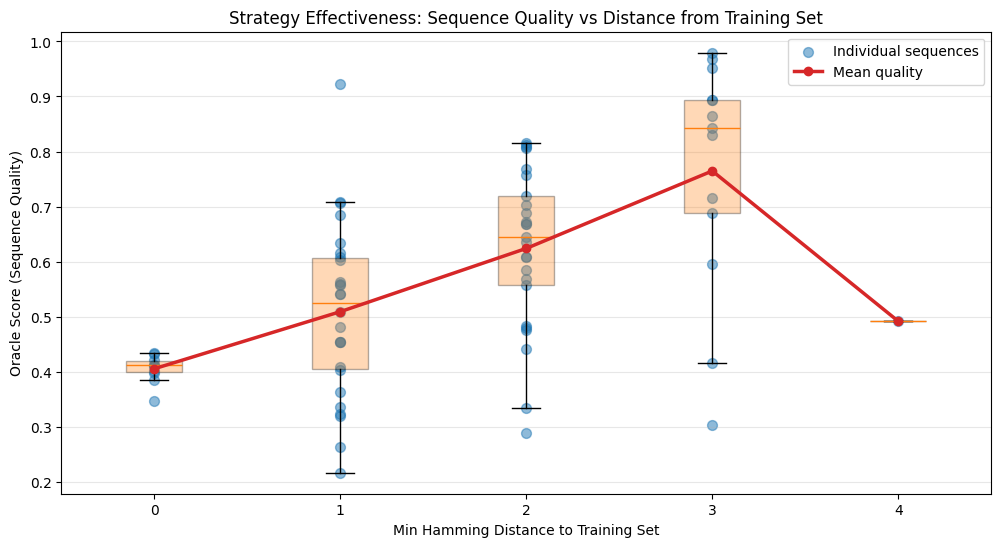

In [ ]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

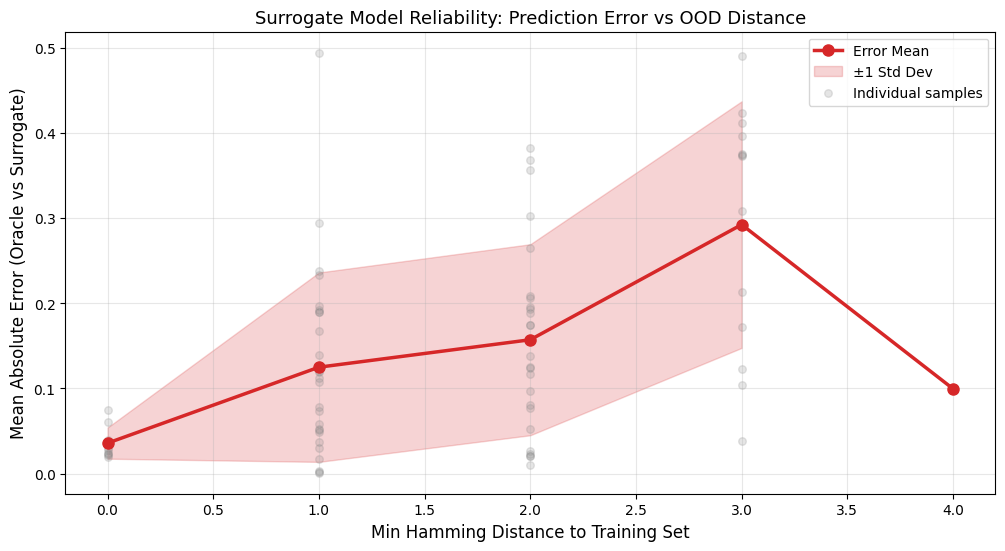

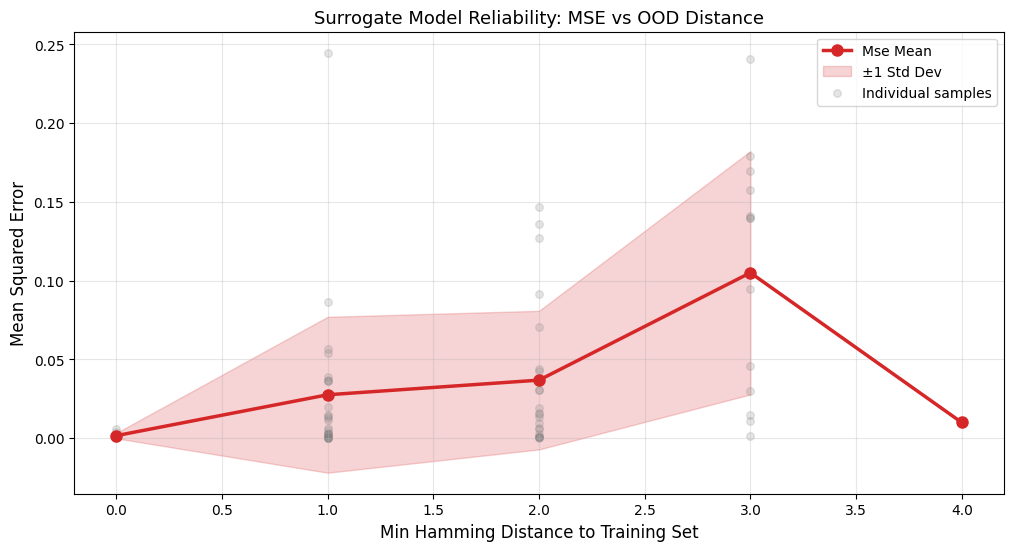

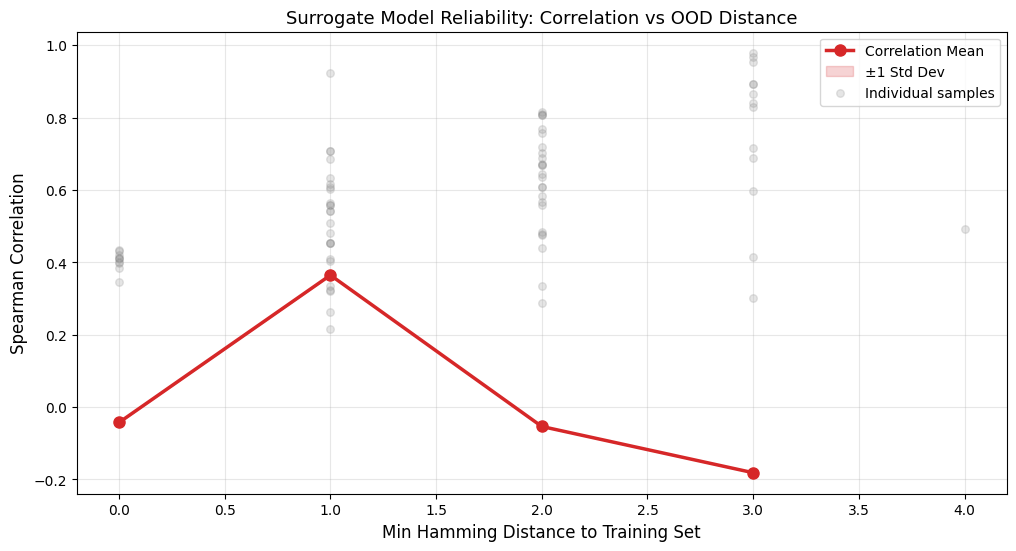

In [ ]:
# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

## Naive Approach on GB1 Data


In [1]:
experiment_runner = ExperimentRunner(keyword = 'smw_gb1')
experiment_runner.run_and_save()

NameError: name 'ExperimentRunner' is not defined

In [3]:
df = pd.read_csv('results/trajectory_smw_gb1.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")


Mean max oracle score: 0.1759 +- 0.0360
Mean median oracle score: -0.0222 +- 0.0184


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

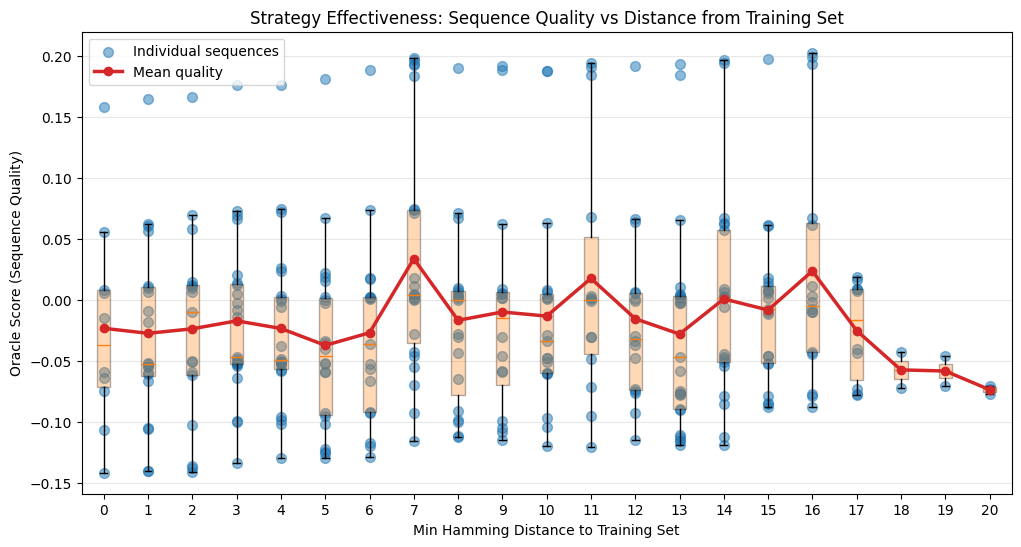

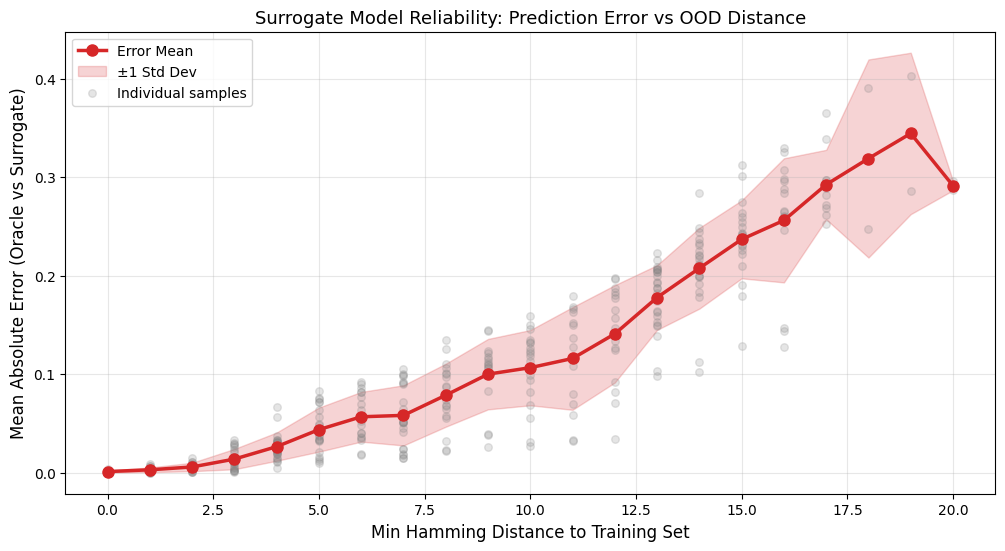

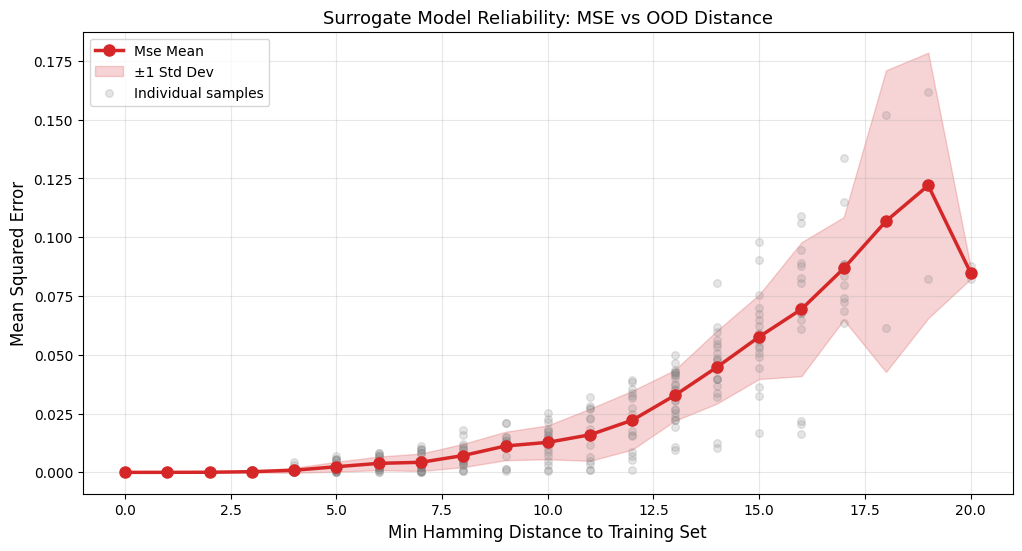

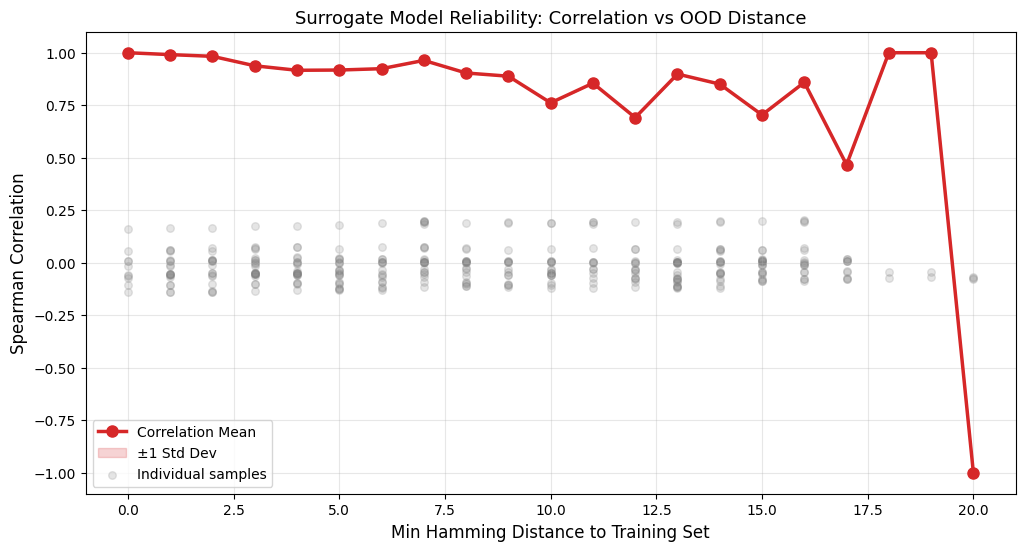

In [4]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

## Reinforcement Appraoch
Scince the naive SMW appraoch is very limited in exploration as the experiments above show, in the following a Reinforcement Learning Approach is used for the same two problems.

In this appraoch the sequences are predicted by a LSTM and scored with a RF. The best 20% of the predicted sequences are then mixed with sequences from the training set and used to retrain the LSTM. 

In [2]:
experiment_runner = ExperimentRunner(keyword='rl_tfbind8')
experiment_runner.run_and_save(parallel=False)


############################################################
Running experiment: rl_tfbind8
Method: rl
Dataset: tfbind8
Runs: 10
Iterations per run: 10
Parallel: False
############################################################


Run 1/10 - RL
Pretraining epoch 0/50, Loss: 1.3205
Pretraining epoch 5/50, Loss: 1.1478
Pretraining epoch 10/50, Loss: 1.0795
Pretraining epoch 15/50, Loss: 1.0457
Pretraining epoch 20/50, Loss: 1.0246
Pretraining epoch 25/50, Loss: 1.0066
Pretraining epoch 30/50, Loss: 0.9935
Pretraining epoch 35/50, Loss: 0.9818
Pretraining epoch 40/50, Loss: 0.9692
Pretraining epoch 45/50, Loss: 0.9576
RL Iteration 1/10 (temp=0.50)
Pretraining epoch 0/20, Loss: 2.2932
Pretraining epoch 5/20, Loss: 1.2700
Pretraining epoch 10/20, Loss: 0.9184
Pretraining epoch 15/20, Loss: 0.7501
RL Iteration 2/10 (temp=0.56)
Pretraining epoch 0/20, Loss: 1.2960
Pretraining epoch 5/20, Loss: 0.8025
Pretraining epoch 10/20, Loss: 0.5873
Pretraining epoch 15/20, Loss: 0.4622
RL Iteration 3/1

,method,run_id,seed,iteration,sequence,oracle_score,surrogate_score,min_hamming_distance,dataset
0,rl,1,43,0,CAAGTTAA,0.260813,0.510561,3,tfbind8
1,rl,1,43,0,ATTGTTAA,0.571290,0.452805,2,tfbind8
2,rl,1,43,0,CAAGTTGT,0.416217,0.456834,3,tfbind8
3,rl,1,43,0,CTTAATGA,0.521770,0.461752,2,tfbind8
4,rl,1,43,0,TTTGTTGA,0.712798,0.437602,2,tfbind8
...,...,...,...,...,...,...,...,...,...
780,rl,10,52,7,TTAATTAA,0.678143,0.464730,2,tfbind8
781,rl,10,52,8,TTAATTAA,0.678143,0.464730,2,tfbind8
782,rl,10,52,8,TTATTAAT,0.726013,0.486785,2,tfbind8
783,rl,10,52,9,TTAATTAA,0.678143,0.464730,2,tfbind8


In [3]:
df = pd.read_csv('results/trajectory_rl_tfbind8_test.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")


Mean max oracle score: 0.8464 +- 0.0535
Mean median oracle score: 0.5933 +- 0.0603


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

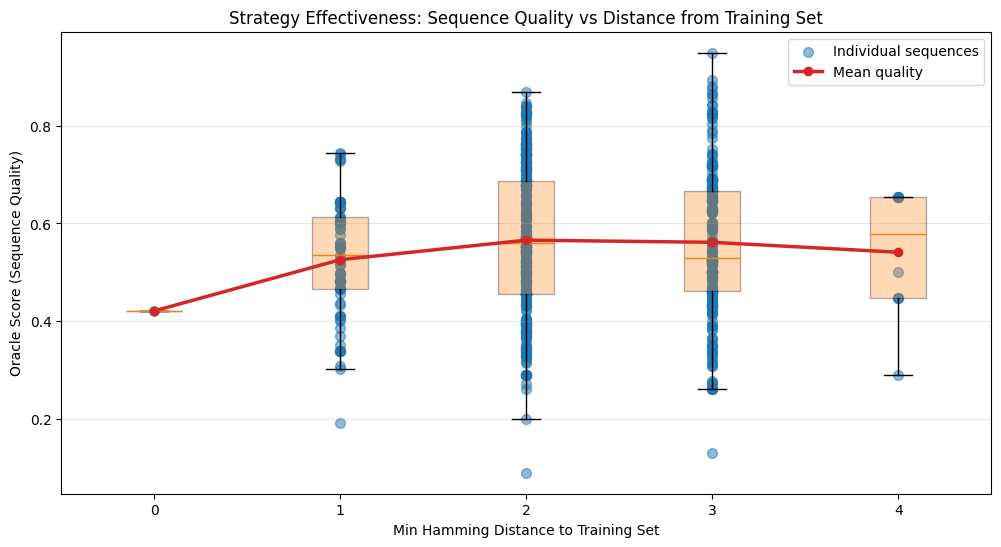

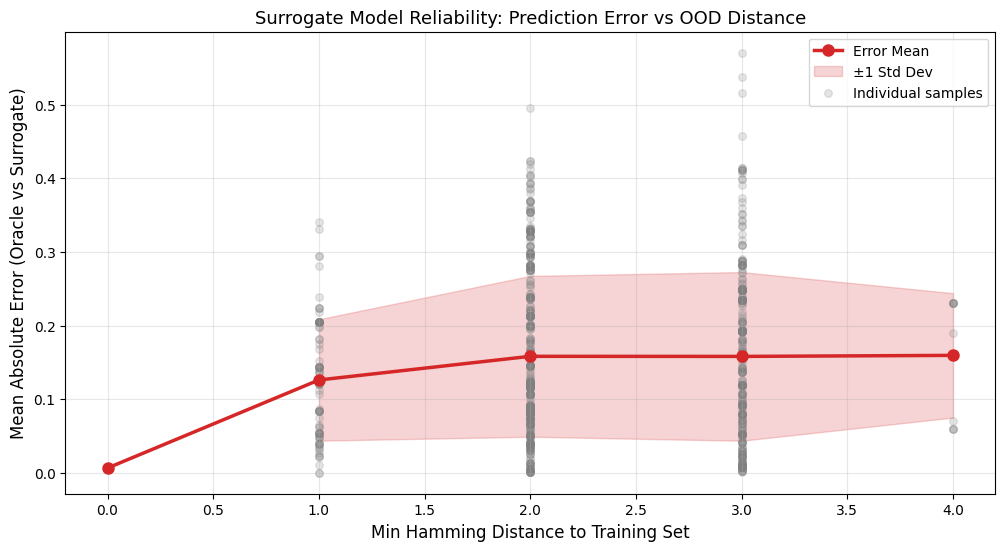

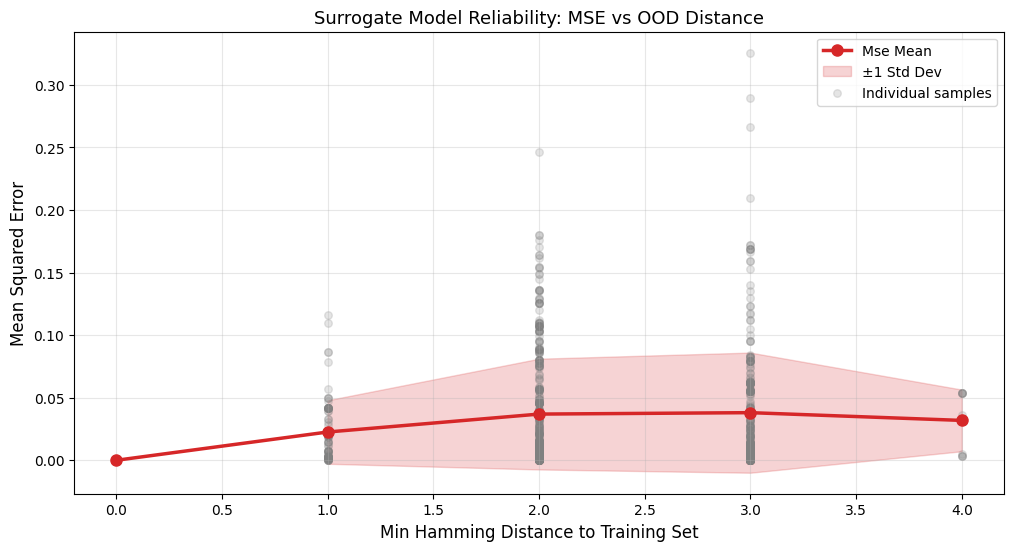

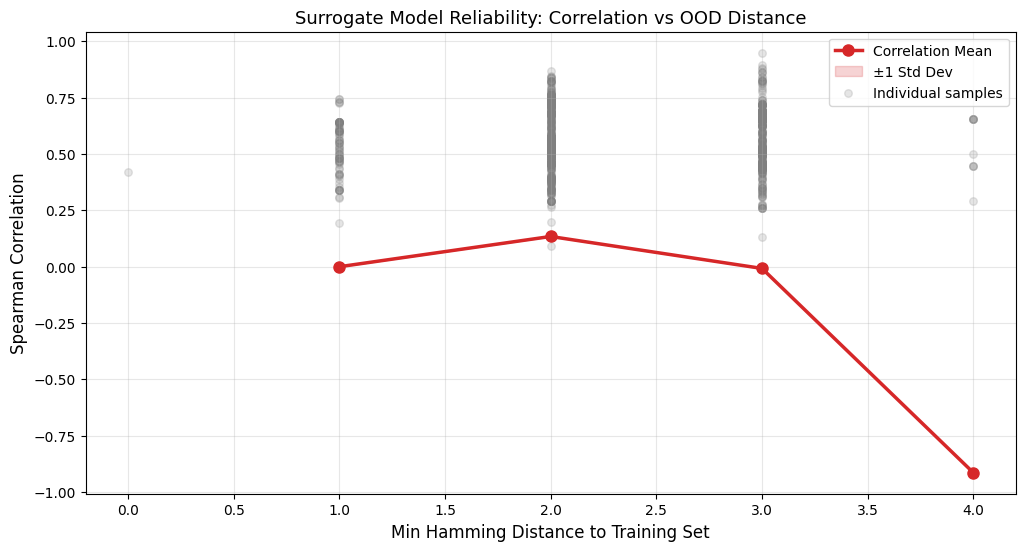

In [4]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

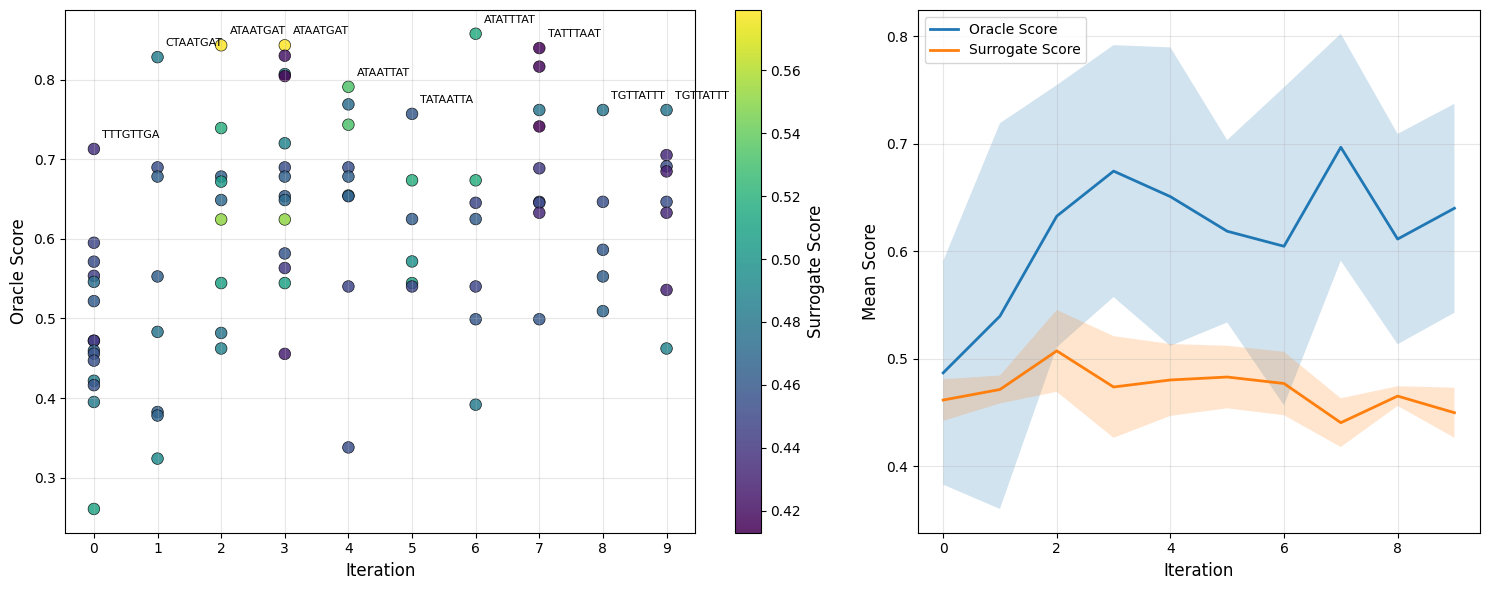

In [5]:
from assets.plot import plot_trajectory_optimization_progress

# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

#### Reinforcement Learning (LSTM + MLP) on GB1 Data

In [3]:
experiment_runner = ExperimentRunner(keyword='rl_gb1')
experiment_runner.run_and_save(parallel=False)


############################################################
Running experiment: rl_gb1
Method: rl
Dataset: gb1
Runs: 10
Iterations per run: 10
Parallel: False
############################################################


Run 1/10 - RL
Selected 16244 training samples.
Pretraining epoch 0/30, Loss: 0.5195
Pretraining epoch 5/30, Loss: 0.1874
Pretraining epoch 10/30, Loss: 0.1757
Pretraining epoch 15/30, Loss: 0.1702
Pretraining epoch 20/30, Loss: 0.1673
Pretraining epoch 25/30, Loss: 0.1651
RL Iteration 1/10 (temp=0.50)
Pretraining epoch 0/20, Loss: 0.6531
Pretraining epoch 5/20, Loss: 0.3850
Pretraining epoch 10/20, Loss: 0.3365
Pretraining epoch 15/20, Loss: 0.2798
RL Iteration 2/10 (temp=0.56)
Pretraining epoch 0/20, Loss: 1.3464
Pretraining epoch 5/20, Loss: 1.1735
Pretraining epoch 10/20, Loss: 0.9135
Pretraining epoch 15/20, Loss: 0.9825
RL Iteration 3/10 (temp=0.61)
Pretraining epoch 0/20, Loss: 4.6892
Pretraining epoch 5/20, Loss: 2.1281
Pretraining epoch 10/20, Loss: 2.4231
P

,method,run_id,seed,iteration,sequence,oracle_score,surrogate_score,min_hamming_distance,dataset
0,rl,1,43,0,WKLIGETGTTTETVTAEKVFKQYANDNGVDGEWTYDDATKTFTVTE...,1.464045,0.274598,48,gb1
1,rl,1,43,0,YKLILNGKTLKGETTTEAVAAATAEKVFKQYANDNGVDGEWTYDDA...,0.175036,-5.226490,49,gb1
2,rl,1,43,0,YKLILNGKTLKGETTTEAVDAAPAEKVFKQYANDNGVDGEWTYDDA...,0.632576,-5.066149,49,gb1
3,rl,1,43,0,WKLIGVTGTTTETVTAAPAEKVFKQYANDNGVDGEWTYDDATKTFT...,-0.666120,-0.088264,46,gb1
4,rl,1,43,0,HKLIGTGTTTTETAEAVAAATAEKVFKQYANDNGVDGEWTYDDATK...,2.917429,-1.479198,48,gb1
...,...,...,...,...,...,...,...,...,...
5065,rl,10,52,9,QILWSHIFDTAQDQQGNSAAPCDDHTRKKRGHYMGDLHNCFNTNSA...,0.643190,0.446055,49,gb1
5066,rl,10,52,9,FAMPWVHHFHHWNCCPHPSQTLHSHNGPVNCYNYNPDMHDACHTMQ...,0.660178,0.579291,52,gb1
5067,rl,10,52,9,WWIQGQCCDMYSWPLHDDMATRNYNAWLCYFQCTMWFFRHNSFQCP...,0.086233,0.424484,53,gb1
5068,rl,10,52,9,HNNPEAWWVIYLTHCWNDSHNVSNQICAASNRCSVRDQNRRGSCTS...,-0.807204,0.460997,52,gb1


Mean max oracle score: 4.9369 +- 1.9697
Mean median oracle score: -0.0103 +- 0.4412


/Users/meier/Documents/MasterThesis/assets/plot.py:418: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(subset[oracle_col], subset[surrogate_col]).correlation


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

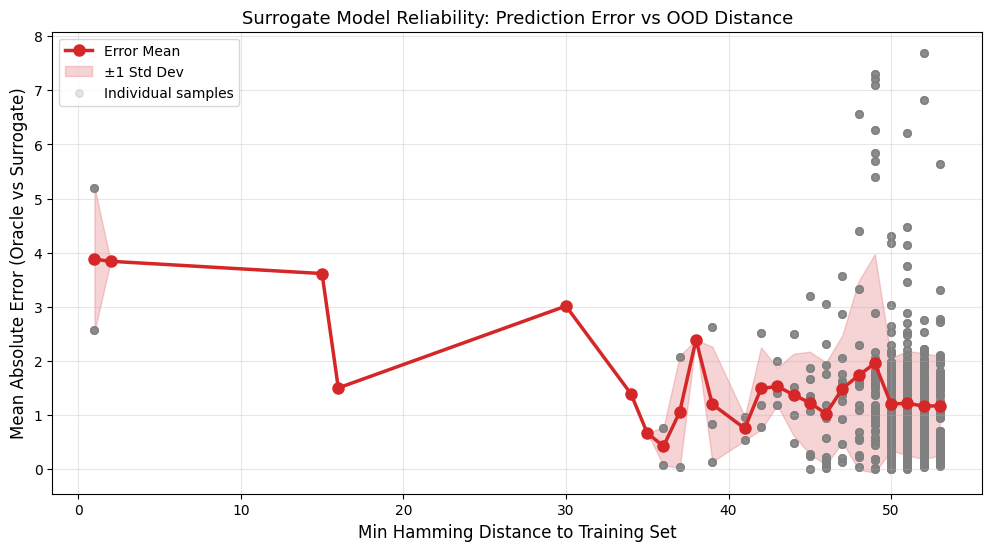

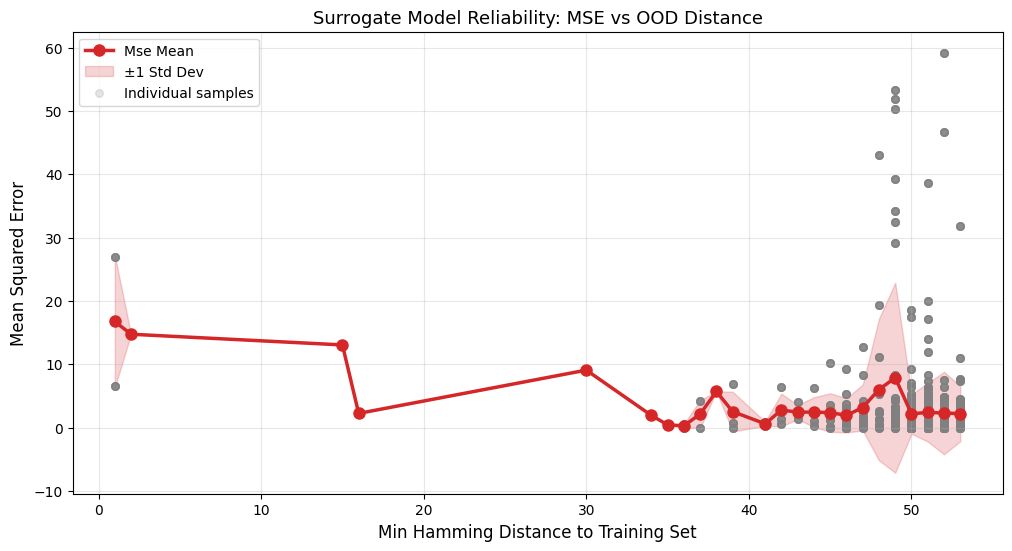

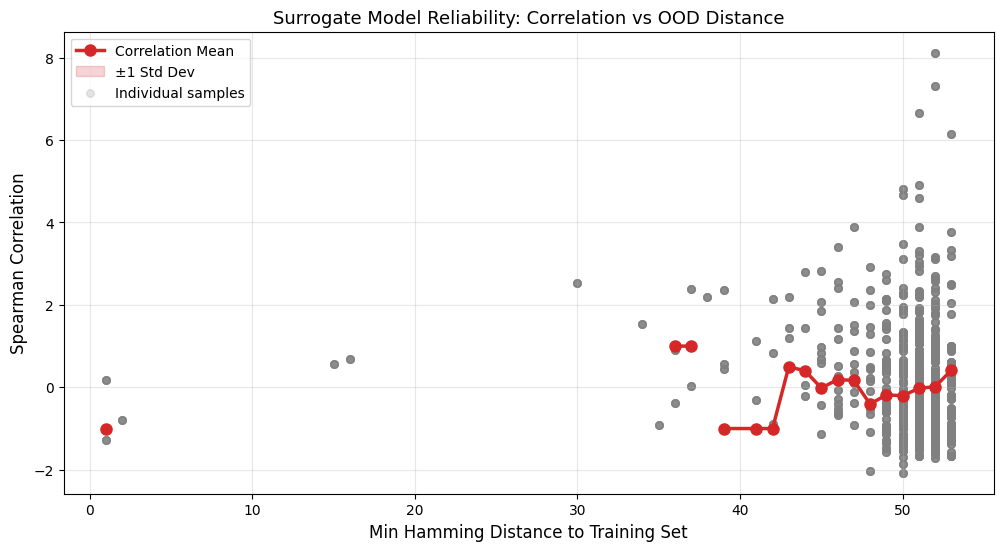

In [4]:
df = pd.read_csv('results/trajectory_rl_gb1_test.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")



# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')


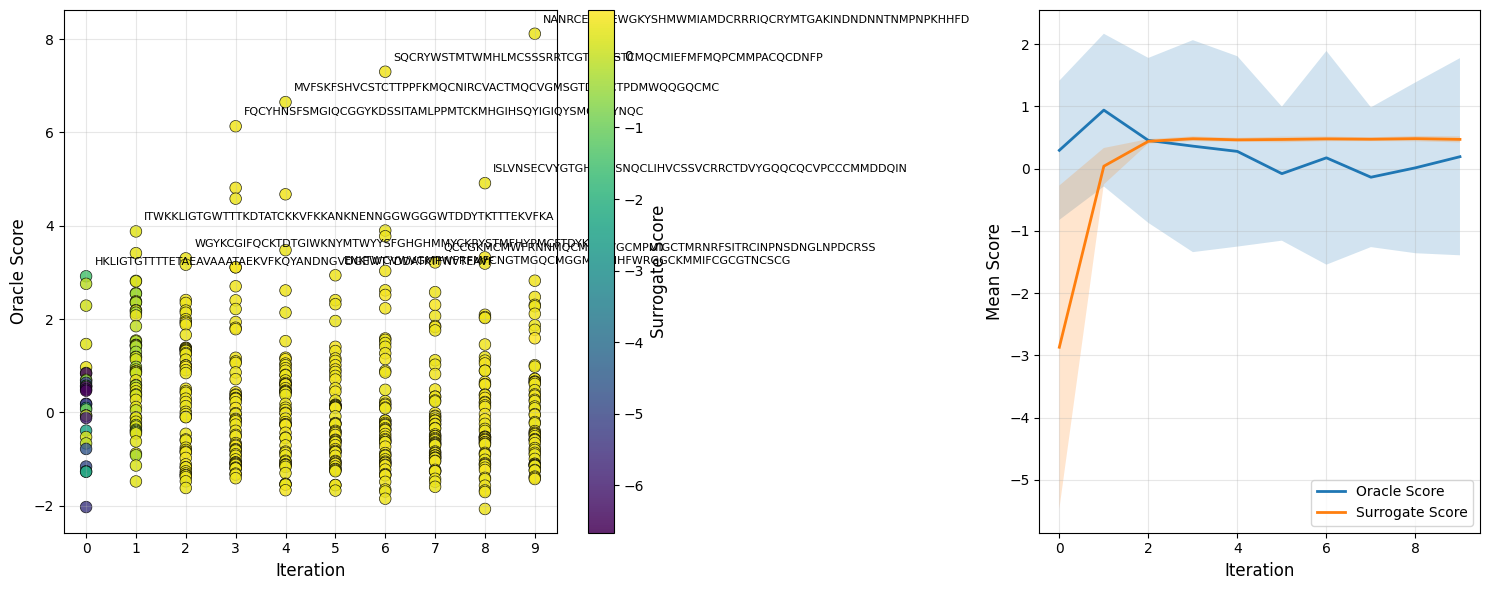

In [5]:
from assets.plot import plot_trajectory_optimization_progress

# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

<Axes: title={'center': 'Strategy Effectiveness: Sequence Quality vs Distance from Training Set'}, xlabel='Min Hamming Distance to Training Set', ylabel='Oracle Score (Sequence Quality)'>

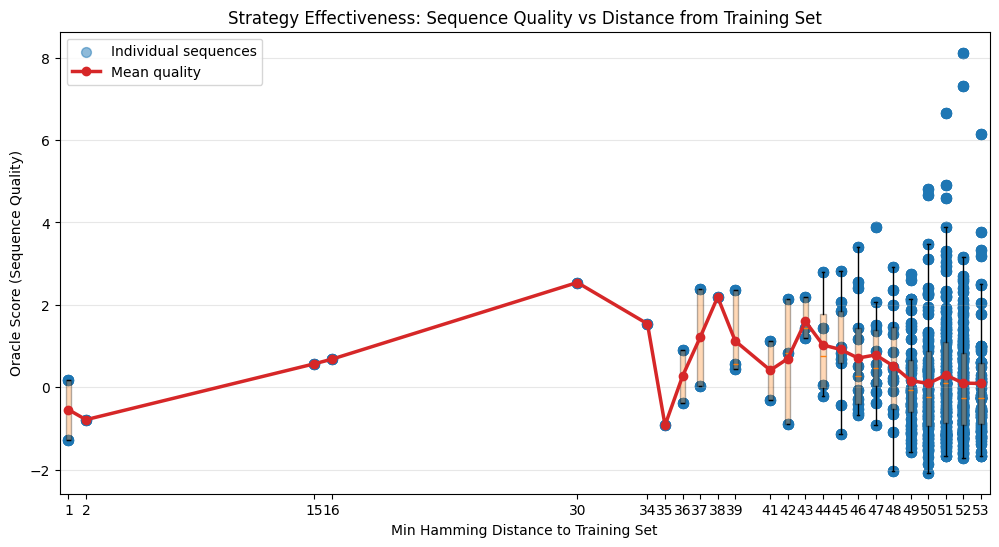

In [6]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

In [7]:
# Count duplicate sequences in the trajectory
num_duplicates = df.duplicated(subset=['sequence']).sum()
print(f"Number of duplicate sequences in the trajectory: {num_duplicates}")
print(f"Total number of sequences in the trajectory: {len(df)}")

Number of duplicate sequences in the trajectory: 0
Total number of sequences in the trajectory: 510


## GFlow Net Experiments

In [1]:
from experiment_runner import ExperimentRunner
import pandas as pd
from assets import compute_metrics
import numpy as np
import matplotlib.pyplot as plt

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
runner = ExperimentRunner(keyword='gfn_tfbind8')
df = runner.run_and_save(parallel=True)


############################################################
Running experiment: gfn_tfbind8
Method: gfn
Dataset: tfbind8
Runs: 10
Iterations per run: 5
Parallel: True
############################################################

Using 10 workers for parallel execution



/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL


Run 7/10 - GFN

Run 4/10 - GFN

Run 2/10 - GFN

Run 9/10 - GFN

Run 1/10 - GFN

Run 10/10 - GFN

Run 6/10 - GFN

Run 3/10 - GFN

Run 5/10 - GFN

Run 8/10 - GFN
Selected 1655 training samples.
Selected 1655 training samples.
Selected 1655 training samples.
Selected 1655 training samples.

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy ensemble...

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy ensemble...

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy ensemble...
Selected 1655 training samples.
Selected 1655 training samples.
Selected 1655 training samples.

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy ensemble...
Selected 1655 training samples.
Selected 1655 training samples.
Selected 1655 training samples.

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy ensemble...

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy ensemble...

GFlowNet-AL Iteration 1/5
  Dataset size: 1655
  Fitting proxy

Mean max oracle score: 0.9810 +- 0.0210
Mean median oracle score: 0.4478 +- 0.0173


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

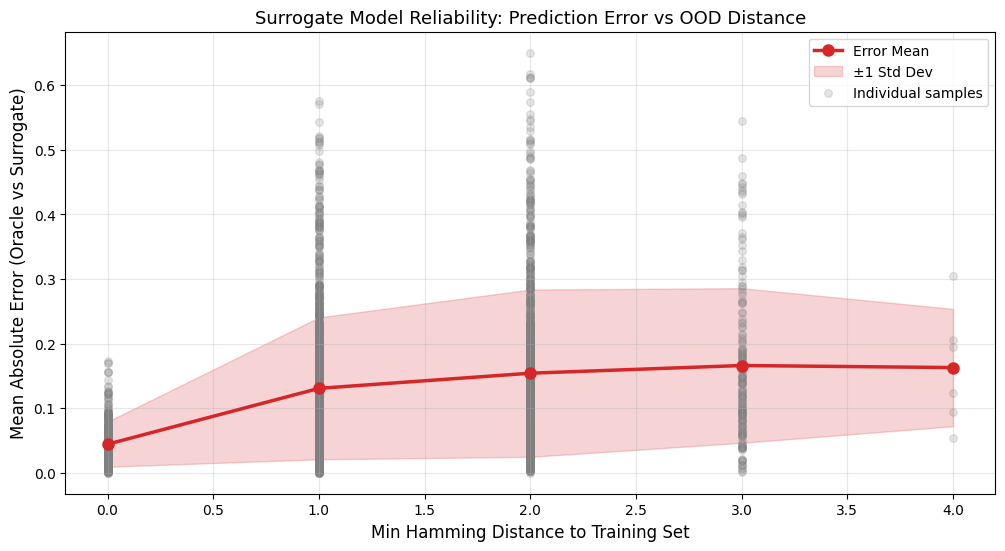

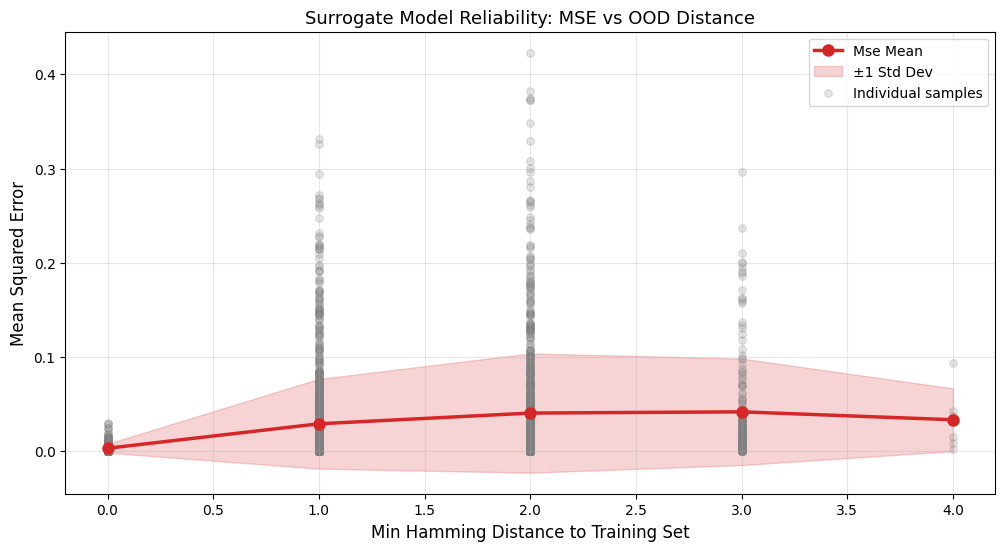

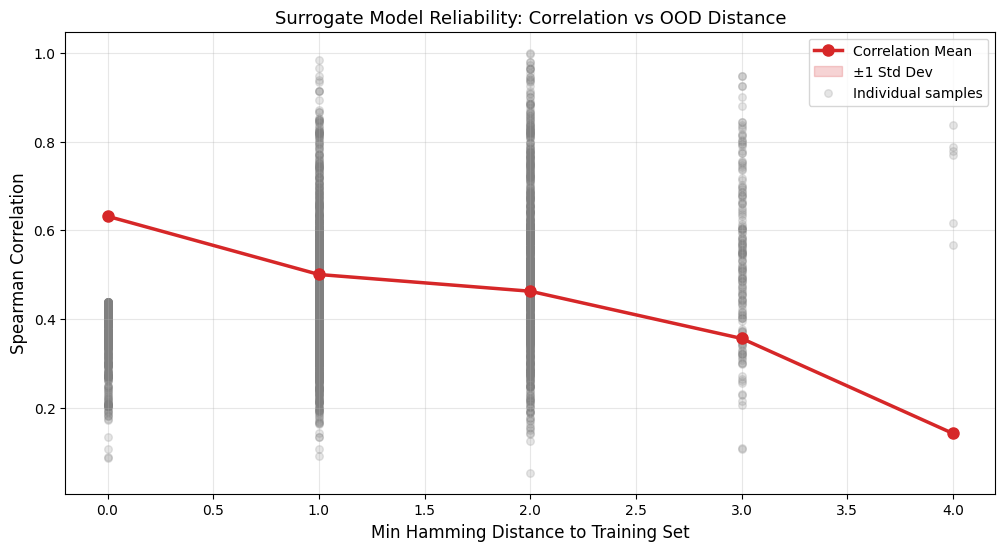

In [11]:
# Calculate stats
df = pd.read_csv('results/trajectory_gfn_tfbind8_test.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")



# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')



<Axes: title={'center': 'Strategy Effectiveness: Sequence Quality vs Distance from Training Set'}, xlabel='Min Hamming Distance to Training Set', ylabel='Oracle Score (Sequence Quality)'>

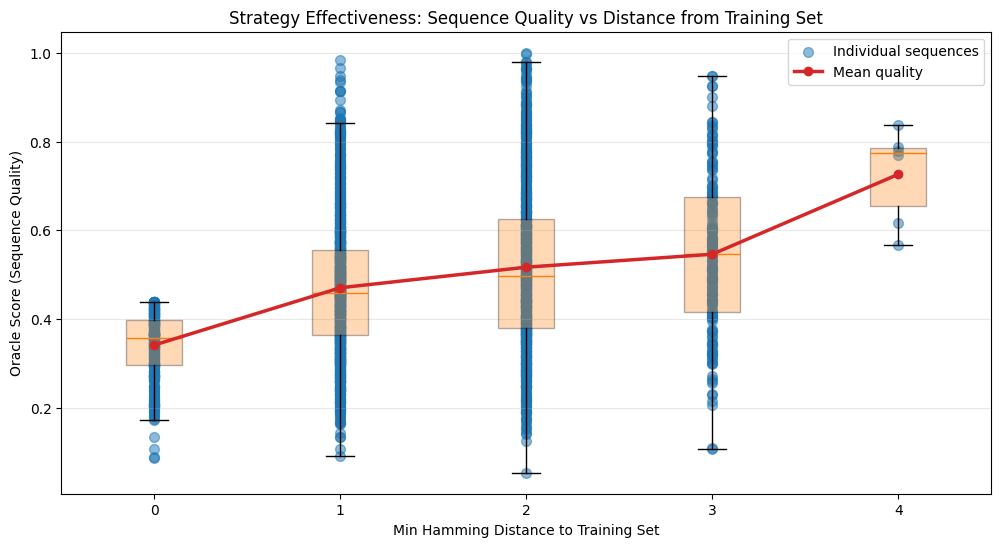

In [12]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

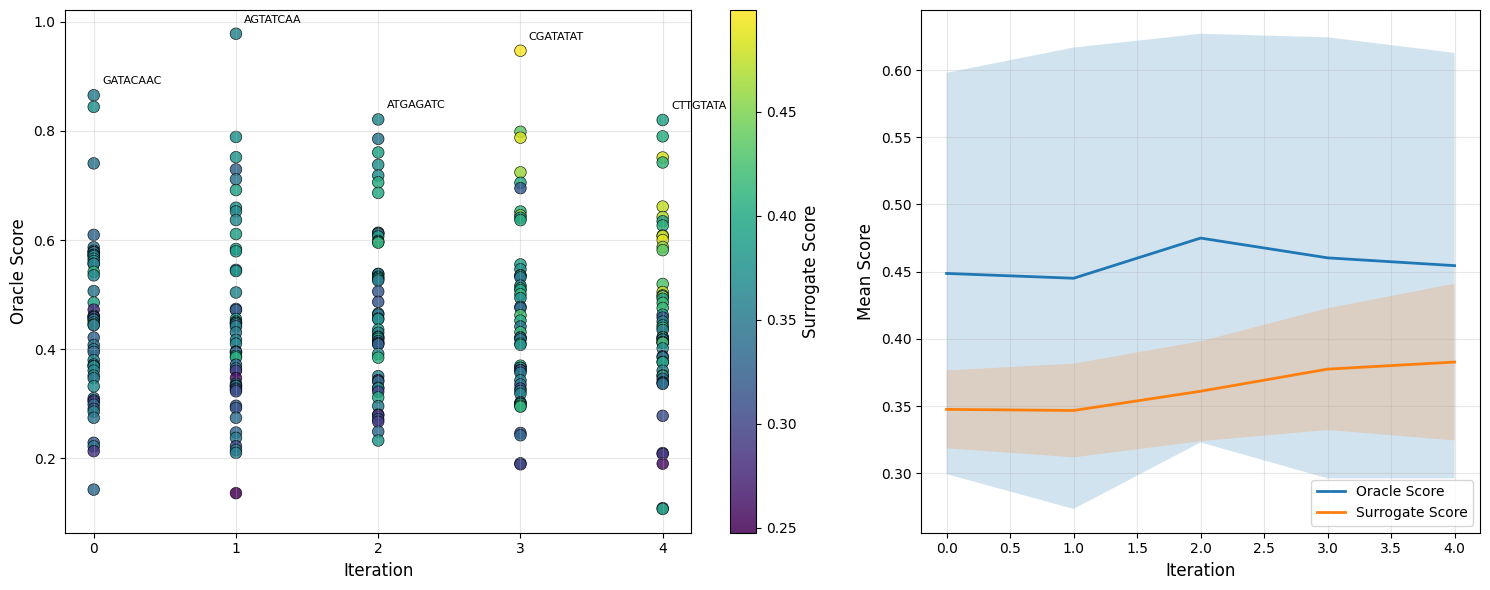

In [13]:
from assets.plot import plot_trajectory_optimization_progress

# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

In [2]:
runner = ExperimentRunner(keyword='gfn_gb1')
df = runner.run_and_save(parallel=True)


############################################################
Running experiment: gfn_gb1
Method: gfn
Dataset: gb1
Runs: 1
Iterations per run: 5
Parallel: True
############################################################

Using 1 workers for parallel execution



/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



Run 1/1 - GFN
Selected 16244 training samples.

GFlowNet-AL Iteration 1/5
  Dataset size: 16244
  Fitting proxy ensemble...
  Training GFlowNet (2000 steps)...
Step 500/2000, TB Loss: 17149.0039, LogZ: 0.4761
Step 1000/2000, TB Loss: 14735.4883, LogZ: 0.9293
Step 1500/2000, TB Loss: 13176.2021, LogZ: 1.3702
Step 2000/2000, TB Loss: 12404.3818, LogZ: 1.8079
  Generating candidates (batch_size=256)...
  Oracle scores — max: 4.5953, mean: 0.4992

GFlowNet-AL Iteration 2/5
  Dataset size: 16448
  Fitting proxy ensemble...
  Training GFlowNet (2000 steps)...
Step 500/2000, TB Loss: 11229.4307, LogZ: 2.3006
Step 1000/2000, TB Loss: 11283.8623, LogZ: 2.7880
Step 1500/2000, TB Loss: 12278.9609, LogZ: 3.2720
Step 2000/2000, TB Loss: 10987.2197, LogZ: 3.7552
  Generating candidates (batch_size=256)...
  Oracle scores — max: 5.4009, mean: 0.5151

GFlowNet-AL Iteration 3/5
  Dataset size: 16652
  Fitting proxy ensemble...
  Training GFlowNet (2000 steps)...
Step 500/2000, TB Loss: 11036.4180, Log

Mean max oracle score: 5.3183 +- 0.6006
Mean median oracle score: 0.3306 +- 0.0837


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

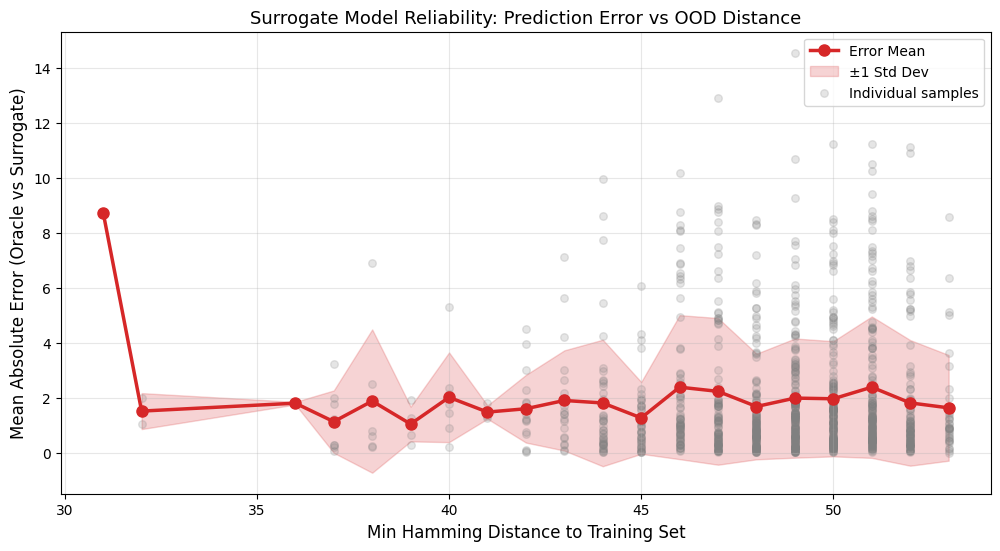

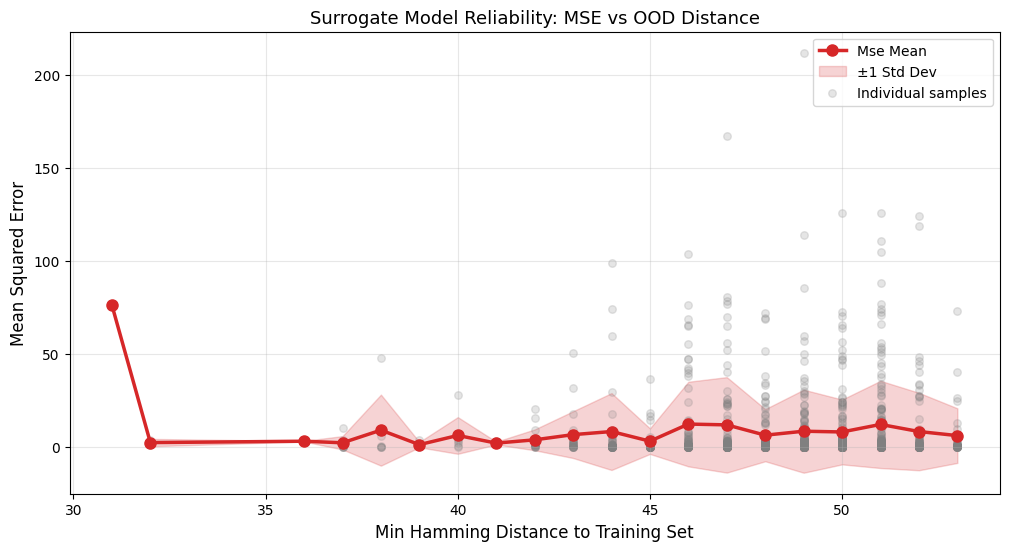

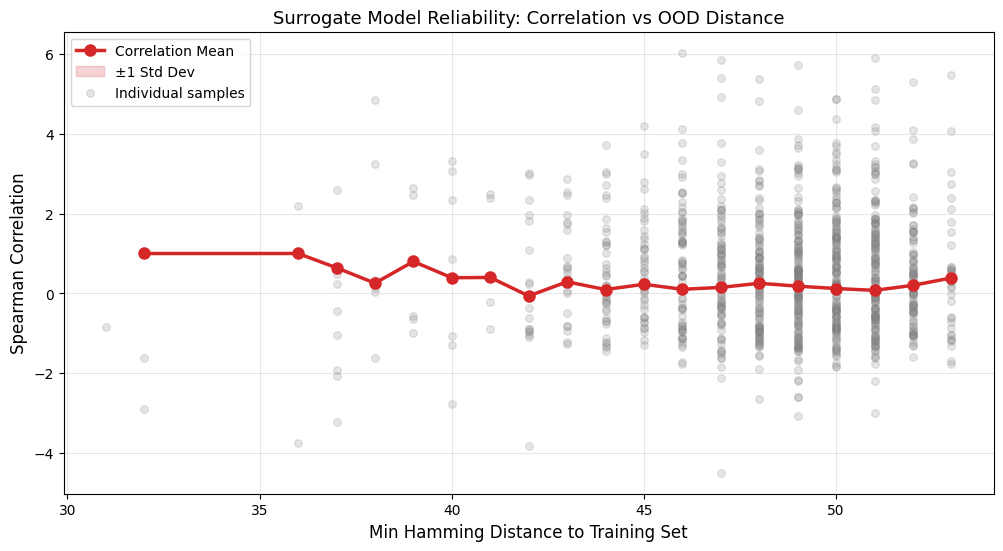

In [5]:
# Calculate stats
df = pd.read_csv('results/trajectory_gfn_gb1_test.csv')

# Calculate mean max oracle score (+- std)
mean_max_oracle_score = df.groupby('iteration')['oracle_score'].max().mean()
standard_deviation_max_oracle_score = df.groupby('iteration')['oracle_score'].max().std()
# Calculate mean median oracle score (+- std)
mean_median_oracle_score = df.groupby('iteration')['oracle_score'].median().mean()
standard_deviation_median_oracle_score = df.groupby('iteration')['oracle_score'].median().std()

print(f"Mean max oracle score: {mean_max_oracle_score:.4f} +- {standard_deviation_max_oracle_score:.4f}")
print(f"Mean median oracle score: {mean_median_oracle_score:.4f} +- {standard_deviation_median_oracle_score:.4f}")



# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')



<Axes: title={'center': 'Strategy Effectiveness: Sequence Quality vs Distance from Training Set'}, xlabel='Min Hamming Distance to Training Set', ylabel='Oracle Score (Sequence Quality)'>

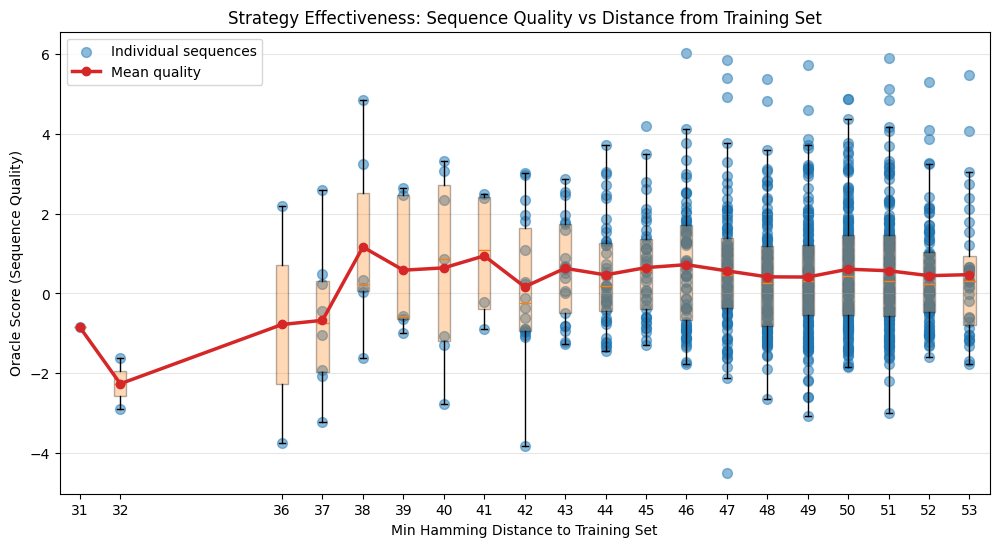

In [6]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

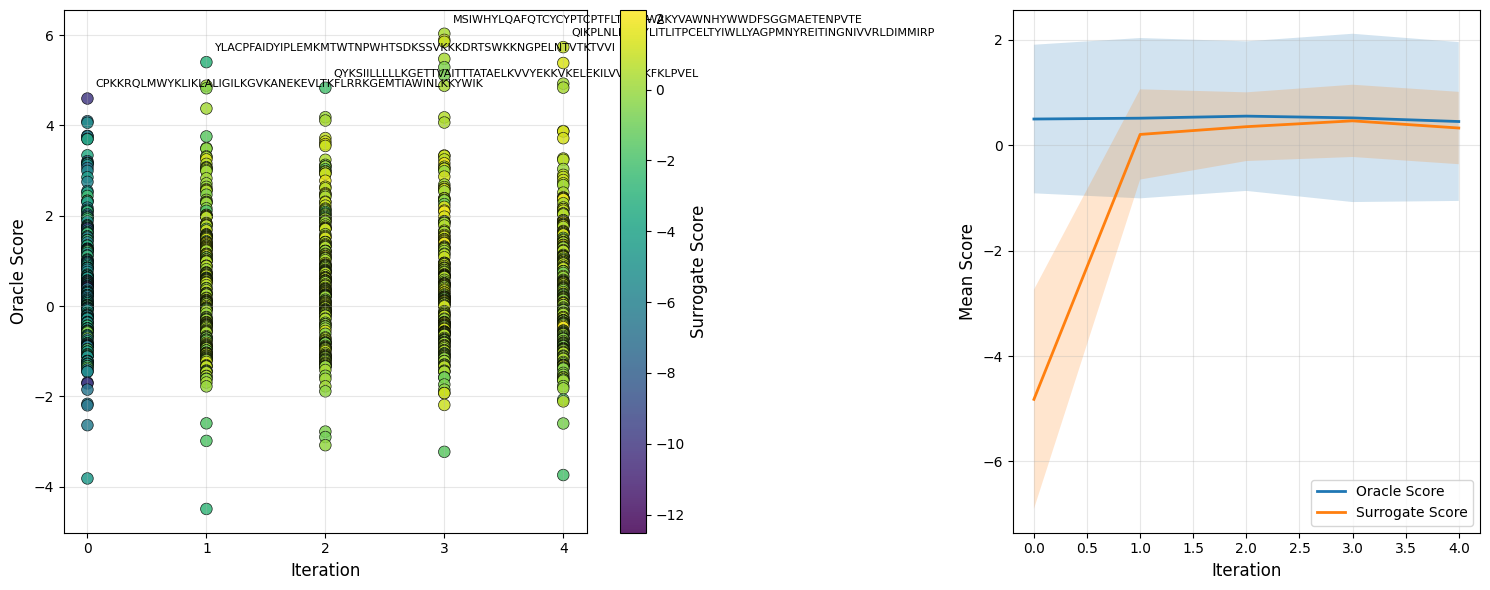

In [7]:
from assets.plot import plot_trajectory_optimization_progress

# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

#### Comparison of all the models

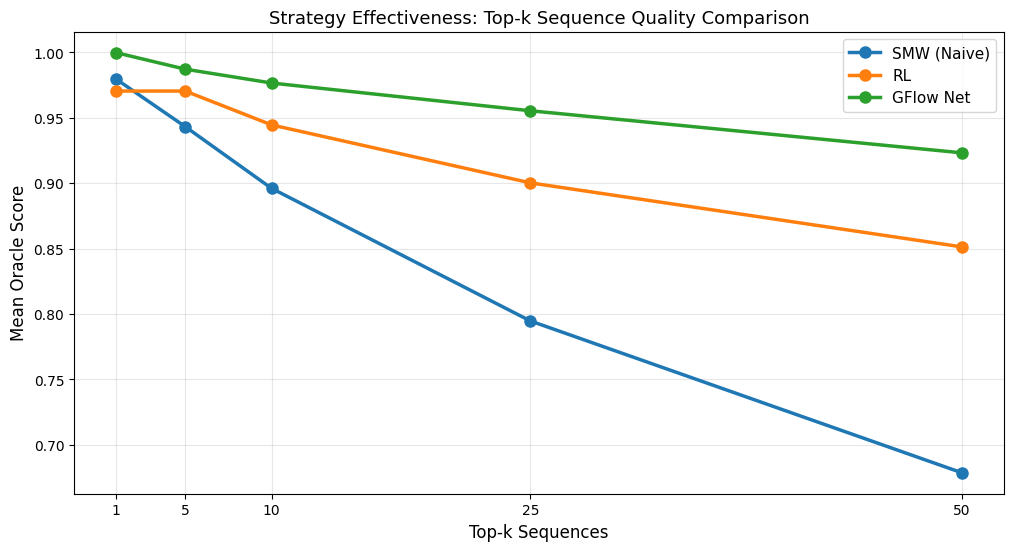

In [8]:
from assets.plot import plot_strategy_comparison_topk
import pandas as pd

# Load trajectory data from each strategy
df_smw = pd.read_csv('results/trajectory_smw_tfbind8.csv')
df_rl = pd.read_csv('results/trajectory_rl_tfbind8.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_tfbind8_test.csv')

# Compare strategies
plot_strategy_comparison_topk({
    'SMW (Naive)': df_smw,
    'RL': df_rl,
    'GFlow Net': df_gfn
})

plt.show()

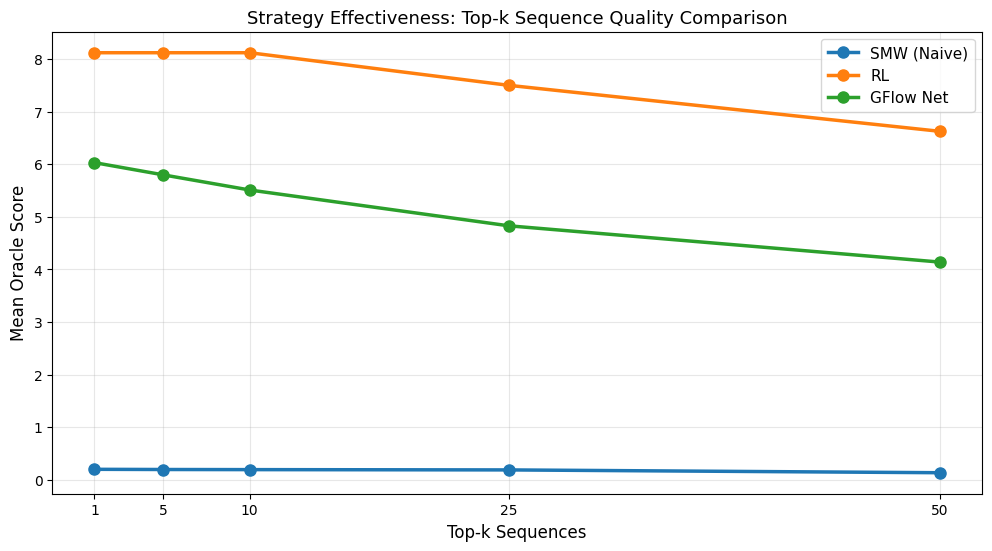

In [9]:
# Load trajectory data from each strategy
df_smw = pd.read_csv('results/trajectory_smw_gb1.csv')
df_rl = pd.read_csv('results/trajectory_rl_gb1_test.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_gb1_test.csv')

# Compare strategies
plot_strategy_comparison_topk({
    'SMW (Naive)': df_smw,
    'RL': df_rl,
    'GFlow Net': df_gfn
})

plt.show()